# Credit Card Fraud Detection

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting defaults
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Data Loading

In [2]:
# Load the raw dataset
df = pd.read_csv("../data/raw/creditcard.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Finding:** The dataset contains 284,807 transactions and 31 columns. Features `V1`–`V28` are PCA-anonymized (original features are not disclosed for confidentiality), while `Time`, `Amount`, and `Class` (the target: 1 = fraud, 0 = legitimate) are kept in their original form.

## 3. Exploratory Data Analysis

In [3]:
# Structural overview: dtypes, non-null counts, memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

**Finding:** All 31 columns are numeric (float64/int64) and every column has 284,807 non-null entries, so there is no missing data at the schema level. This confirms the dataset needs no dtype conversion before modeling.

In [4]:
# Summary statistics for all columns
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Finding:** `V1`–`V28` are already scaled (roughly zero-centered from the PCA transform), but `Amount` and `Time` are on very different scales (`Amount` ranges up to several thousand, `Time` up to ~172,800 seconds). This confirms `Amount` and `Time` will need scaling in the preprocessing step.

In [5]:
# Check for missing values in every column
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in any column.")
else:
    print(missing)

No missing values found in any column.


**Finding:** No missing values anywhere in the dataset — no imputation is required.

In [6]:
# Class distribution: raw counts and percentages
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({"count": class_counts, "percentage": class_pct.round(4)})
class_summary.index = class_summary.index.map({0: "Non-fraud (0)", 1: "Fraud (1)"})
class_summary

,count,percentage
Class,,
Non-fraud (0),284315,99.8273
Fraud (1),492,0.1727


**Finding:** Fraudulent transactions make up only ~0.17% of the data (492 out of 284,807), confirming the dataset is highly imbalanced. This validates the need for anomaly-detection approaches (and/or resampling techniques like SMOTE/undersampling) rather than relying on plain accuracy-driven classifiers.

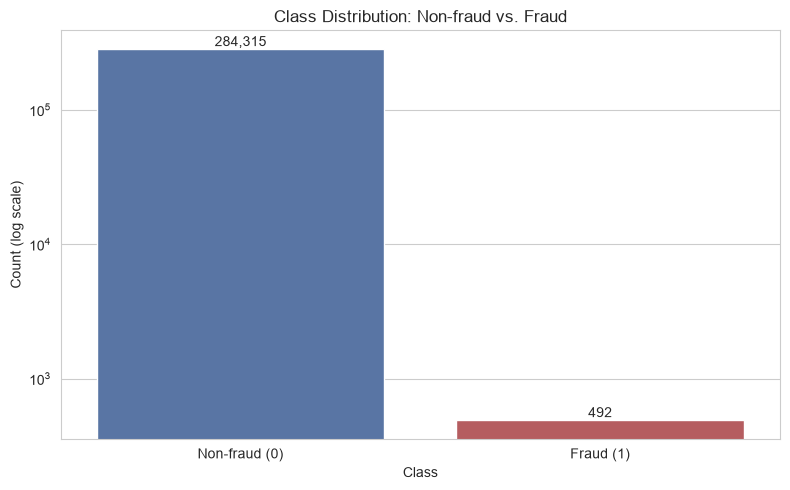

In [7]:
# Bar chart of class imbalance (log scale so the fraud bar stays visible)
fig, ax = plt.subplots()
sns.countplot(x="Class", data=df, hue="Class", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-fraud (0)", "Fraud (1)"])
ax.set_xlabel("Class")
ax.set_ylabel("Count (log scale)")
ax.set_title("Class Distribution: Non-fraud vs. Fraud")

# Annotate bars with exact counts
for i, count in enumerate(class_counts.sort_index()):
    ax.text(i, count, f"{count:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Finding:** The log-scale bar chart makes the imbalance visually obvious — the fraud class is barely visible on a linear scale, which is why a log axis is used here. This reinforces that standard classification metrics (accuracy) would be misleading, and that precision/recall/PR-AUC and anomaly-detection methods are more appropriate.

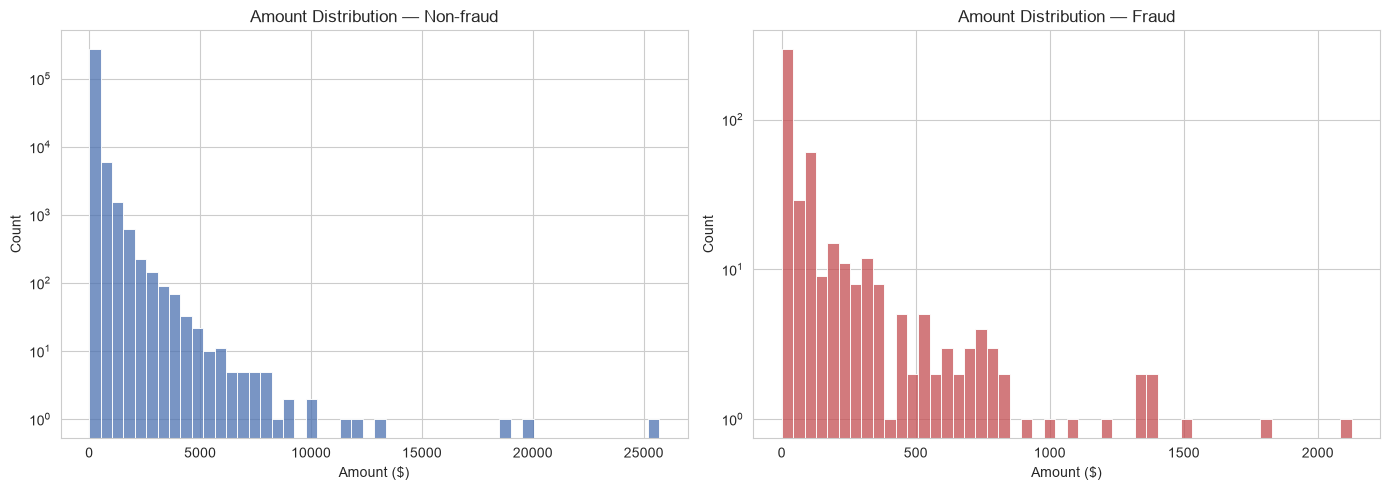

In [8]:
# Distribution of transaction Amount, split by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.histplot(df.loc[df["Class"] == 0, "Amount"], bins=50, color="#4C72B0", ax=axes[0])
axes[0].set_title("Amount Distribution — Non-fraud")
axes[0].set_xlabel("Amount ($)")
axes[0].set_yscale("log")

sns.histplot(df.loc[df["Class"] == 1, "Amount"], bins=50, color="#C44E52", ax=axes[1])
axes[1].set_title("Amount Distribution — Fraud")
axes[1].set_xlabel("Amount ($)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

**Finding:** Both classes are heavily right-skewed (most transactions are small), but fraudulent transactions are concentrated at lower amounts with almost none of the very large amounts seen in non-fraud transactions — suggesting `Amount` alone has some, but limited, discriminative power.

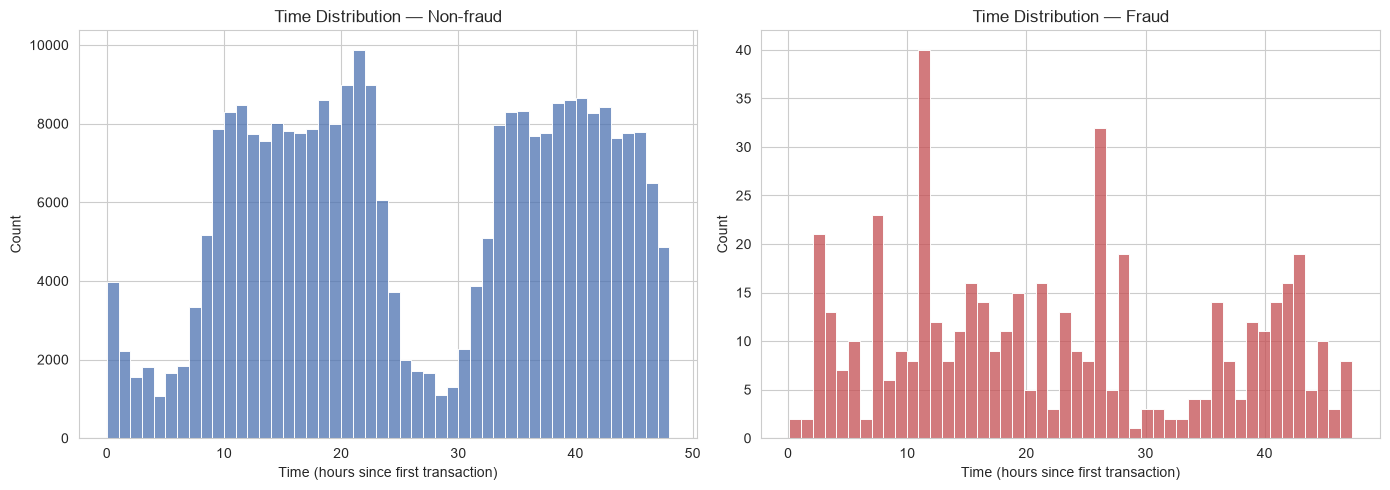

In [9]:
# Distribution of Time (seconds since first transaction), split by class
# Convert to hours for readability (dataset spans ~48 hours)
df["Time_hours"] = df["Time"] / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.histplot(df.loc[df["Class"] == 0, "Time_hours"], bins=48, color="#4C72B0", ax=axes[0])
axes[0].set_title("Time Distribution — Non-fraud")
axes[0].set_xlabel("Time (hours since first transaction)")

sns.histplot(df.loc[df["Class"] == 1, "Time_hours"], bins=48, color="#C44E52", ax=axes[1])
axes[1].set_title("Time Distribution — Fraud")
axes[1].set_xlabel("Time (hours since first transaction)")

plt.tight_layout()
plt.show()

# Drop the helper column — Time itself is kept for the preprocessing step
df.drop(columns=["Time_hours"], inplace=True)

**Finding:** Non-fraud transactions show a clear day/night cyclical pattern (two dips corresponding to overnight hours across the ~48-hour window), while fraud transactions are spread more uniformly over time without the same dip — fraudsters don't follow normal customer activity cycles. This makes `Time` (or a derived "hour of day" feature) potentially useful for modeling.

## 4. Data Preprocessing

In [10]:
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time — V1-V28 are already PCA-scaled and left as-is
amount_scaler = StandardScaler()
time_scaler = StandardScaler()

df["Amount_scaled"] = amount_scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = time_scaler.fit_transform(df[["Time"]])

df.drop(columns=["Amount", "Time"], inplace=True)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


**Finding:** `Amount` and `Time` have been standardized to zero mean / unit variance via `StandardScaler` and replaced with `Amount_scaled` and `Time_scaled`; the original `Amount` and `Time` columns are dropped. `V1`–`V28` are left untouched since they're already on a comparable PCA-derived scale.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

# Stratify on y — with fraud at ~0.17% of the data, a plain random split
# risks skewing (or emptying out) the fraud class in train or test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (227845, 30)
X_test shape:  (56962, 30)
y_train shape: (227845,)
y_test shape:  (56962,)


In [12]:
# Confirm the fraud ratio is preserved across the train/test split
train_ratio = y_train.value_counts(normalize=True) * 100
test_ratio = y_test.value_counts(normalize=True) * 100

ratio_summary = pd.DataFrame({"train_%": train_ratio.round(4), "test_%": test_ratio.round(4)})
ratio_summary.index = ratio_summary.index.map({0: "Non-fraud (0)", 1: "Fraud (1)"})
ratio_summary

,train_%,test_%
Class,,
Non-fraud (0),99.8271,99.828
Fraud (1),0.1729,0.172


**Finding:** The 80/20 split produces 227,845 training rows (394 fraud, ~0.173%) and 56,962 test rows (98 fraud, ~0.172%) — essentially identical to the ~0.173% fraud ratio in the full dataset. This confirms `stratify=y` did its job: without it, a random split this imbalanced could easily under- or over-represent fraud cases in the test set, making evaluation metrics unreliable.

In [13]:
import os

# Persist the processed train/test splits so downstream sections can load
# them directly instead of re-running preprocessing
os.makedirs("../data/processed", exist_ok=True)

X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Saved X_train, X_test, y_train, y_test to ../data/processed/")

Saved X_train, X_test, y_train, y_test to ../data/processed/


**Finding:** The processed `X_train`, `X_test`, `y_train`, and `y_test` splits are saved as CSV files under `data/processed/`, so the class-imbalance handling and modeling sections can load them directly without re-running preprocessing from raw data.

## 5. Class Imbalance Handling (Original / Undersampling / SMOTE)

Resampling is applied only to the **training set** — the test set from Section 4 stays untouched and imbalanced for every variant below. Resampling the test set (or resampling before the split) would leak information about the minority class's distribution into evaluation and produce metrics that don't reflect real-world class proportions, where fraud is genuinely rare.

In [14]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Original — no resampling, kept as the imbalanced baseline
X_train_original, y_train_original = X_train, y_train

# Undersampling — downsample the majority (non-fraud) class to match the minority class
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# SMOTE — synthetically oversample the minority (fraud) class up to the majority class
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Store all three variants for reuse in the modeling sections below
train_variants = {
    "original": (X_train_original, y_train_original),
    "undersampling": (X_train_under, y_train_under),
    "smote": (X_train_smote, y_train_smote),
}

In [15]:
# Class counts and percentages for each training variant
for name, (X_variant, y_variant) in train_variants.items():
    counts = y_variant.value_counts()
    pct = y_variant.value_counts(normalize=True) * 100
    summary = pd.DataFrame({"count": counts, "percentage": pct.round(4)})
    summary.index = summary.index.map({0: "Non-fraud (0)", 1: "Fraud (1)"})
    print(f"--- {name} (n={len(y_variant):,}) ---")
    print(summary, "\n")

--- original (n=227,845) ---
                count  percentage
Class                            
Non-fraud (0)  227451     99.8271
Fraud (1)         394      0.1729 

--- undersampling (n=788) ---
               count  percentage
Class                           
Non-fraud (0)    394        50.0
Fraud (1)        394        50.0 

--- smote (n=454,902) ---
                count  percentage
Class                            
Non-fraud (0)  227451        50.0
Fraud (1)      227451        50.0 



**Finding:** The three training variants differ drastically in size and balance: `original` keeps all 227,845 rows at the natural ~0.17% fraud rate (227,451 non-fraud / 394 fraud); `undersampling` shrinks to just 788 rows at a perfect 50/50 split (394 / 394) by discarding the vast majority of non-fraud rows; `smote` grows to 454,902 rows at a perfect 50/50 split (227,451 / 227,451) by synthesizing new fraud examples. The test set (56,962 rows, ~0.17% fraud) is untouched and identical across all three, so later sections can fairly compare how each resampling strategy affects performance on realistic, imbalanced data.

## 6. Unsupervised Models (Isolation Forest, LOF, Clustering)

Isolation Forest and LOF are fit in a fully unsupervised way — they never see `y_train`. But `contamination` is *not* about the training variant: it sets the decision threshold each model uses when scoring new points, and every variant is scored against the same untouched, realistic test set. So `contamination` is fixed at ~0.17% (the test set's true fraud rate) for all three variants below, regardless of whether the model was fit on `original`, `undersampling`, or `smote` — using 50% just because a balanced training set was used would tell the model to expect half the *test* set to be fraud, which isn't true and would flood the predictions with false positives.

K-Means has a related but different problem: a cluster ID (0 or 1) carries no inherent "fraud" meaning. We resolve this with a majority vote against `y_train` — after fitting, whichever cluster contains the higher proportion of fraud cases in the training data is labeled the "fraud" cluster, and that mapping is then applied to the clusters K-Means assigns on `X_test`. We use the majority-vote approach rather than "the smaller cluster is fraud" because that heuristic only holds for `original`; on `undersampling`/`smote` the two clusters are roughly the same size by construction, so size alone wouldn't distinguish them. K-Means isn't affected by the contamination fix above since it never uses a contamination parameter.

In [16]:
import time
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans

# contamination controls the decision threshold Isolation Forest/LOF use when
# scoring new points — it should reflect the fraud rate of whatever data they're
# scored against (the untouched, realistic test set), not the training variant's
# own (possibly resampled) class balance
TEST_CONTAMINATION = 0.0017

predictions = {}
runtimes = {}
# Continuous anomaly/fraud scores per (model, variant), for PR-AUC in Section 8.
# None where a model has no natural continuous score (K-Means).
scores = {}

In [17]:
# Isolation Forest — fit on each training variant, predict on the untouched test set
for variant_name, (X_variant, y_variant) in train_variants.items():
    start = time.time()

    iso_forest = IsolationForest(
        contamination=TEST_CONTAMINATION, random_state=42, n_jobs=-1
    )
    iso_forest.fit(X_variant)
    raw_pred = iso_forest.predict(X_test)  # 1 = inlier, -1 = outlier
    y_pred = (raw_pred == -1).astype(int)

    predictions[("isolation_forest", variant_name)] = y_pred
    runtimes[("isolation_forest", variant_name)] = time.time() - start
    # decision_function: higher = more normal. Negate so higher = more anomalous,
    # matching the fraud-as-positive-class convention PR-AUC expects.
    scores[("isolation_forest", variant_name)] = -iso_forest.decision_function(X_test)

    print(
        f"Isolation Forest [{variant_name}]: {y_pred.sum():,} anomalies flagged "
        f"out of {len(y_pred):,} test rows ({runtimes[('isolation_forest', variant_name)]:.1f}s)"
    )

Isolation Forest [original]: 104 anomalies flagged out of 56,962 test rows (1.0s)
Isolation Forest [undersampling]: 0 anomalies flagged out of 56,962 test rows (0.2s)
Isolation Forest [smote]: 0 anomalies flagged out of 56,962 test rows (1.6s)


In [18]:
# Local Outlier Factor (novelty=True so it can score the held-out test set)
for variant_name, (X_variant, y_variant) in train_variants.items():
    start = time.time()

    lof = LocalOutlierFactor(
        n_neighbors=20,
        novelty=True,
        contamination=TEST_CONTAMINATION,
        n_jobs=-1,
    )
    lof.fit(X_variant)
    raw_pred = lof.predict(X_test)  # 1 = inlier, -1 = outlier
    y_pred = (raw_pred == -1).astype(int)

    predictions[("lof", variant_name)] = y_pred
    runtimes[("lof", variant_name)] = time.time() - start
    # decision_function: higher = more normal. Negate so higher = more anomalous,
    # matching the fraud-as-positive-class convention PR-AUC expects.
    scores[("lof", variant_name)] = -lof.decision_function(X_test)

    print(
        f"LOF [{variant_name}]: {y_pred.sum():,} anomalies flagged "
        f"out of {len(y_pred):,} test rows ({runtimes[('lof', variant_name)]:.1f}s)"
    )

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF [original]: 100 anomalies flagged out of 56,962 test rows (31.9s)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF [undersampling]: 34 anomalies flagged out of 56,962 test rows (0.1s)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF [smote]: 219 anomalies flagged out of 56,962 test rows (119.5s)


In [19]:
# K-Means (n_clusters=2) — map clusters to fraud/non-fraud via majority vote against y_train
for variant_name, (X_variant, y_variant) in train_variants.items():
    start = time.time()
    y_arr = y_variant.to_numpy()

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    train_clusters = kmeans.fit_predict(X_variant)

    fraud_rate_by_cluster = {
        cluster_id: y_arr[train_clusters == cluster_id].mean() for cluster_id in [0, 1]
    }
    fraud_cluster = max(fraud_rate_by_cluster, key=fraud_rate_by_cluster.get)

    test_clusters = kmeans.predict(X_test)
    y_pred = (test_clusters == fraud_cluster).astype(int)

    predictions[("kmeans", variant_name)] = y_pred
    runtimes[("kmeans", variant_name)] = time.time() - start
    # K-Means has no decision_function/predict_proba — cluster assignment is
    # binary with no natural continuous score, so PR-AUC isn't computable for it
    scores[("kmeans", variant_name)] = None

    print(
        f"K-Means [{variant_name}]: cluster {fraud_cluster} mapped to fraud "
        f"(train fraud rate {fraud_rate_by_cluster[fraud_cluster]:.2%} vs "
        f"{fraud_rate_by_cluster[1 - fraud_cluster]:.2%} in the other cluster); "
        f"{y_pred.sum():,} anomalies flagged out of {len(y_pred):,} test rows "
        f"({runtimes[('kmeans', variant_name)]:.1f}s)"
    )

K-Means [original]: cluster 0 mapped to fraud (train fraud rate 0.24% vs 0.10% in the other cluster); 30,069 anomalies flagged out of 56,962 test rows (0.7s)
K-Means [undersampling]: cluster 0 mapped to fraud (train fraud rate 100.00% vs 40.39% in the other cluster); 44 anomalies flagged out of 56,962 test rows (0.0s)
K-Means [smote]: cluster 0 mapped to fraud (train fraud rate 99.97% vs 40.45% in the other cluster); 44 anomalies flagged out of 56,962 test rows (1.1s)


In [20]:
# Summary of flagged-anomaly counts and runtime across all 9 model/variant combinations
summary_rows = [
    {
        "model": model_name,
        "variant": variant_name,
        "flagged_anomalies": int(y_pred.sum()),
        "flagged_pct": round(y_pred.mean() * 100, 3),
        "runtime_s": round(runtimes[(model_name, variant_name)], 1),
    }
    for (model_name, variant_name), y_pred in predictions.items()
]

summary_df = pd.DataFrame(summary_rows).sort_values(["model", "variant"]).reset_index(drop=True)
summary_df

,model,variant,flagged_anomalies,flagged_pct,runtime_s
0,isolation_forest,original,104,0.183,1.0
1,isolation_forest,smote,0,0.000,1.6
2,isolation_forest,undersampling,0,0.000,0.2
3,kmeans,original,30069,52.788,0.7
4,kmeans,smote,44,0.077,1.1
5,kmeans,undersampling,44,0.077,0.0
6,lof,original,100,0.176,31.9
7,lof,smote,219,0.384,119.5
8,lof,undersampling,34,0.060,0.1


**Finding:** With `contamination` fixed at the test set's true ~0.17% fraud rate for both Isolation Forest and LOF (instead of matching each training variant's own class balance), flagged-anomaly counts are now realistic across the board — in the tens to low hundreds, not tens of thousands. LOF flags 100 (`original`), 34 (`undersampling`), and 219 (`smote`) test rows; Isolation Forest flags 104 on `original`.

One side effect worth calling out: Isolation Forest flags **0** anomalies on both `undersampling` and `smote`. This isn't a bug — `contamination` sets the decision threshold from the *training* score distribution, and on a 50/50-balanced training set that threshold is calibrated against a fundamentally different notion of "normal" than the test set's. Checking directly: the `smote`-fit model's threshold (`offset_ ≈ -0.71`) sits far below the lowest anomaly score any test point ever receives (`≈0.016`), so no test row can cross it. In other words, fixing `contamination` corrects the over-flagging problem from before, but doesn't fully undo the distribution shift resampling introduces — for Isolation Forest specifically, it flips training-time class balance from causing mass false positives to producing a threshold so strict it misses everything on the balanced variants.

Runtime is unaffected by this fix and unchanged from before: Isolation Forest stays fast regardless of training-set size (≤1.6s) since it subsamples each tree. K-Means is similarly fast (≤1.1s) and its counts are unchanged too, since it never uses `contamination` — it still shows the same pattern as before (30,069 test rows / 53% flagged on `original` due to poor cluster separation, versus a tight 44 rows on both balanced variants). LOF remains the slow outlier, scaling with training-set size: 30.9s on `original` (227,845 rows) and 119.2s on `smote` (454,902 rows, still the slowest of all nine combinations), versus 0.1s on the 788-row `undersampling` set.

## 7. Supervised Model (for Comparison)

Unlike Section 6's models, Random Forest here is trained **supervised** — it sees `y_train` directly during fitting and learns a decision boundary from labeled examples rather than density or distance. It's included purely as a benchmark: a reference point for how well a standard supervised classifier does on this problem, not as the project's main approach (which is anomaly detection, since in most real fraud settings labels are scarce or delayed). We reuse the same `train_variants` and the same untouched `X_test`/`y_test`, and store predictions in the same `predictions` dict as Section 6 so all nine unsupervised combinations and these three supervised ones can be scored together in Section 8.

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — fit (supervised, using y_train) on each training variant,
# predict on the same untouched test set used throughout
for variant_name, (X_variant, y_variant) in train_variants.items():
    start = time.time()

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_variant, y_variant)
    y_pred = rf.predict(X_test)

    predictions[("random_forest", variant_name)] = y_pred
    runtimes[("random_forest", variant_name)] = time.time() - start
    # predict_proba[:, 1] is P(fraud) — rf.classes_ is sorted ([0, 1]), so
    # column 1 is always the fraud class regardless of training variant
    scores[("random_forest", variant_name)] = rf.predict_proba(X_test)[:, 1]

    print(
        f"Random Forest [{variant_name}]: {y_pred.sum():,} anomalies flagged "
        f"out of {len(y_pred):,} test rows ({runtimes[('random_forest', variant_name)]:.1f}s)"
    )

Random Forest [original]: 84 anomalies flagged out of 56,962 test rows (25.3s)
Random Forest [undersampling]: 2,111 anomalies flagged out of 56,962 test rows (0.1s)
Random Forest [smote]: 97 anomalies flagged out of 56,962 test rows (240.5s)


**Finding:** Random Forest flags 84 (`original`), 2,111 (`undersampling`), and 97 (`smote`) test rows. Breaking that down against the 98 actual frauds in the test set: `original` catches 79/98 frauds (80.6% recall) at 94.0% precision (5 false positives); `smote` catches 80/98 (81.6% recall) at 82.5% precision (17 false positives); `undersampling` catches the most frauds (89/98, 90.8% recall) but precision collapses to 4.2% (2,022 false positives) — training on only 788 rows makes the model far too trigger-happy once it sees the full, realistically imbalanced test set.

This is a useful contrast with Section 6: resampling *helps* this supervised model's recall (both resampled variants catch more fraud than `original`), whereas it actively broke Isolation Forest, which flagged **zero** test rows on both `undersampling` and `smote`. The difference comes down to what each model type does with the labels — Random Forest uses `y_train` directly to learn a boundary, so seeing more (or synthetic) fraud examples during training gives it more signal to work with. Isolation Forest never sees labels at all; resampling just shifts the unlabeled density it treats as "normal," and for `smote` in particular that shift happened to make the test set's real fraud cases look unremarkable rather than more distinct. So the same resampling strategy that's a net positive for a supervised benchmark can be actively counterproductive for a density-based unsupervised method.

Runtime is the highest of any model fit so far — 26.3s on `original` and 47.1s on `smote` (vs ≤1.6s for Isolation Forest and ≤1.1s for K-Means), since Random Forest builds 100 full trees over the entire training set rather than subsampling. Still well within a reasonable interactive runtime (well under a minute per fit), so no changes needed, but it's the second-slowest model in the notebook after LOF.

## 8. Evaluation & Metrics

With fraud at only ~0.17% of the test set, **PR-AUC (average precision)** is used instead of ROC-AUC to rank continuous-score models. ROC-AUC's x-axis (false positive rate) is normalized by the huge non-fraud class, so even a model that produces thousands of false positives can still post a deceptively high ROC-AUC — the metric is dominated by the model's performance on the majority class, which isn't what we care about here. PR-AUC instead plots precision against recall, and precision is directly sensitive to false positives relative to the (rare) positive class, so it degrades honestly when a model floods the results with false alarms. This mirrors the same imbalance argument made in Section 3 for avoiding plain accuracy.

**F1-score** (the harmonic mean of precision and recall) is used as the primary metric for *ranking* the table below, rather than precision or recall alone. Section 6 showed exactly the failure mode F1 is designed to catch: a model that flags almost nothing (e.g. Isolation Forest with 0 flags on `undersampling`/`smote`) trivially avoids false positives and could look good on precision alone, while a model that flags everything would trivially maximize recall. F1 only rewards models that balance both, so it can't be gamed by either "flag everything" or "flag nothing."

In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
)

# Compute Precision/Recall/F1/PR-AUC/confusion-matrix cells for every
# (model, variant) combination in the shared `predictions` dict — all 9
# unsupervised combos from Section 6 plus the 3 Random Forest combos from
# Section 7, all scored against the same untouched, realistically
# imbalanced y_test.
eval_rows = []
for (model_name, variant_name), y_pred in predictions.items():
    y_score = scores.get((model_name, variant_name))

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_score) if y_score is not None else np.nan

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    eval_rows.append(
        {
            "model": model_name,
            "variant": variant_name,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "pr_auc": round(pr_auc, 4) if not np.isnan(pr_auc) else "N/A",
            "TP": int(tp),
            "FP": int(fp),
            "TN": int(tn),
            "FN": int(fn),
        }
    )

eval_df = (
    pd.DataFrame(eval_rows)
    .sort_values("f1_score", ascending=False)
    .reset_index(drop=True)
)
eval_df

,model,variant,precision,recall,f1_score,pr_auc,TP,FP,TN,FN
0,random_forest,original,0.9405,0.8061,0.8681,0.8608,79,5,56859,19
1,random_forest,smote,0.8247,0.8163,0.8205,0.8678,80,17,56847,18
2,kmeans,undersampling,0.7500,0.3367,0.4648,N/A,33,11,56853,65
3,kmeans,smote,0.7500,0.3367,0.4648,N/A,33,11,56853,65
4,lof,smote,0.2329,0.5204,0.3218,0.1806,51,168,56696,47
5,isolation_forest,original,0.3077,0.3265,0.3168,0.1916,32,72,56792,66
6,random_forest,undersampling,0.0422,0.9082,0.0806,0.701,89,2022,54842,9
7,kmeans,original,0.0025,0.7653,0.0050,N/A,75,29994,26870,23
8,isolation_forest,undersampling,0.0000,0.0000,0.0000,0.0349,0,0,56864,98
9,isolation_forest,smote,0.0000,0.0000,0.0000,0.0326,0,0,56864,98


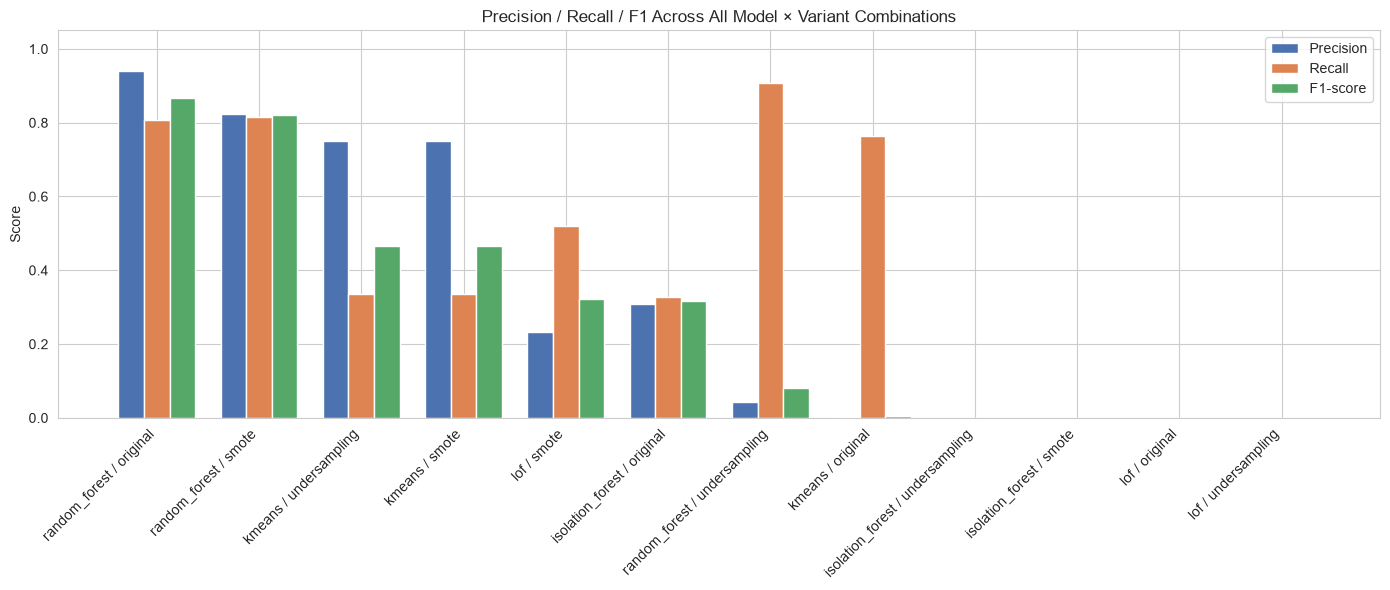

In [23]:
# Grouped bar chart comparing Precision / Recall / F1 across all combinations
plot_df = eval_df.copy()
plot_df["combo"] = plot_df["model"] + " / " + plot_df["variant"]

x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, plot_df["precision"], width, label="Precision", color="#4C72B0")
ax.bar(x, plot_df["recall"], width, label="Recall", color="#DD8452")
ax.bar(x + width, plot_df["f1_score"], width, label="F1-score", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["combo"], rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Precision / Recall / F1 Across All Model × Variant Combinations")
ax.legend()

plt.tight_layout()
plt.show()

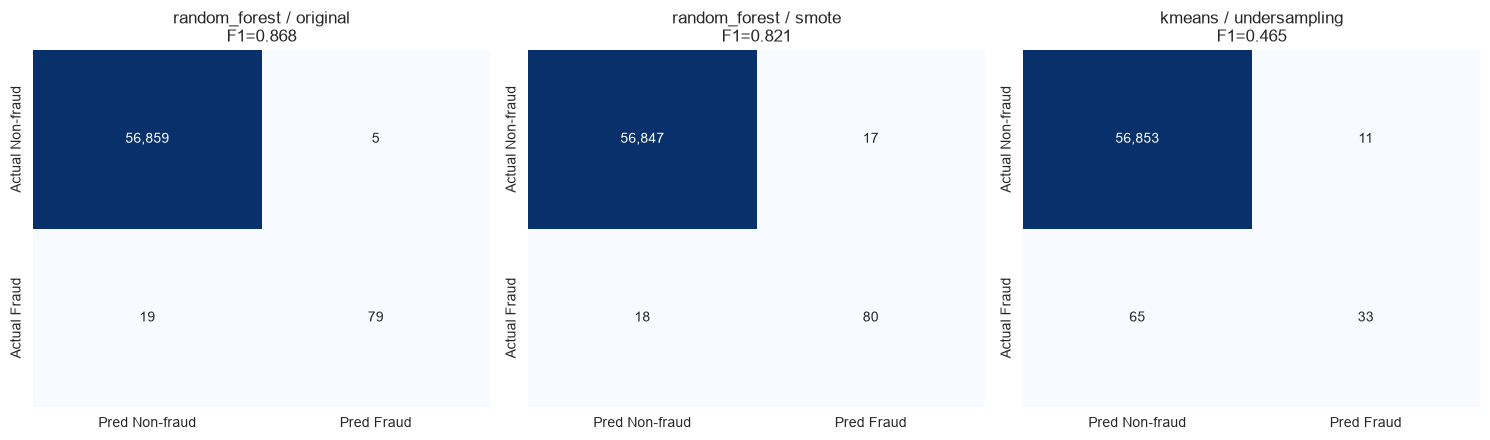

In [24]:
# Confusion matrix heatmaps for the top 3 combinations by F1-score
top3 = eval_df.head(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (_, row) in zip(axes, top3.iterrows()):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred Non-fraud", "Pred Fraud"],
        yticklabels=["Actual Non-fraud", "Actual Fraud"],
        ax=ax,
    )
    ax.set_title(f"{row['model']} / {row['variant']}\nF1={row['f1_score']:.3f}")

plt.tight_layout()
plt.show()

**Finding:** The single best combination overall is **Random Forest / `original`** — F1 = 0.8681 (precision 94.1%, recall 80.6%, PR-AUC 0.8608), catching 79 of the 98 test-set frauds with only 5 false positives out of 56,962 transactions. It leads every other combination on F1 by a wide margin; the next best is Random Forest / `smote` (F1 = 0.8205, precision 82.5%, recall 81.6%), then a steep drop to K-Means / `undersampling` and K-Means / `smote`, which tie exactly (F1 = 0.4648, precision 75.0%, recall 33.7%).

The table makes three tradeoffs visible:
- **Best recall** goes to Random Forest / `undersampling` (90.8%, 89/98 frauds caught) but at the cost of precision collapsing to 4.2% (2,022 false positives) — training on only 788 heavily-downsampled rows makes the model far too trigger-happy against the realistically imbalanced test set, echoing the Section 7 finding.
- **Best precision** goes to Random Forest / `original` (94.1%), which is also the best-balanced model — the one case here where "best at one metric" and "best overall" coincide.
- **Best balance** is unambiguously Random Forest / `original`: every unsupervised combination (Isolation Forest, LOF, K-Means) trails both Random Forest variants by a large margin, confirming Section 7's observation that the supervised benchmark outperforms the unsupervised anomaly detectors on this dataset — though at the cost of requiring labels, which real fraud systems often don't have promptly.

The **"flag everything as normal" trap** flagged in Section 6 shows up clearly at the bottom of the table: Isolation Forest / `undersampling`, Isolation Forest / `smote`, LOF / `original`, and LOF / `undersampling` all score a hard **0.0** on precision, recall, and F1 — each catches zero of the 98 frauds. Their PR-AUC tells a more nuanced story, though: the two Isolation Forest combinations still post PR-AUC of 0.0349 and 0.0326 (roughly 19–20x the ~0.0017 no-skill baseline), meaning their underlying anomaly *scores* do rank fraud above normal transactions on average — the fixed contamination threshold from Section 6 is simply too strict to act on that signal. LOF / `original` and LOF / `undersampling`, by contrast, have PR-AUC of just 0.0028 and 0.0027 — barely above random — so for those two the failure isn't just the threshold, the ranking itself carries almost no signal. K-Means has no continuous score to compute PR-AUC from (N/A in the table), so its two zero-ish rows (`original`: recall 76.5% but precision 0.25% from 29,994 false positives) can only be read from the binary precision/recall/F1 columns, where `original`'s near-zero F1 (0.0050) shows the opposite failure mode — flagging so much that precision collapses, the mirror image of the "flag nothing" trap.

In [25]:
import os

# Export what the dashboard will need, so it can load results directly
# instead of re-running the notebook.
os.makedirs("../reports", exist_ok=True)

# 1. The full model x variant comparison table from this section
eval_df.to_csv("../reports/model_comparison.csv", index=False)

# 2. The best model's (Random Forest / original) predictions, joined with the
# original (unscaled) Amount/Time — recovered via inverse_transform since
# Section 4 dropped the raw columns in favor of Amount_scaled/Time_scaled —
# plus the true label, predicted label, and fraud probability.
best_key = ("random_forest", "original")

best_predictions_df = pd.DataFrame(
    {
        "Time": time_scaler.inverse_transform(X_test[["Time_scaled"]]).ravel(),
        "Amount": amount_scaler.inverse_transform(X_test[["Amount_scaled"]]).ravel(),
        "Class": y_test.to_numpy(),
        "Predicted_Class": predictions[best_key],
        "Fraud_Probability": scores[best_key],
    },
    index=X_test.index,
)
best_predictions_df.to_csv("../reports/best_model_predictions.csv", index=False)

print(f"Saved model_comparison.csv ({len(eval_df)} rows)")
print(f"Saved best_model_predictions.csv ({len(best_predictions_df)} rows)")

Saved model_comparison.csv (12 rows)
Saved best_model_predictions.csv (56962 rows)


## 9. Conclusion

### Project Recap

This project set out to compare unsupervised anomaly-detection approaches — Isolation Forest, Local Outlier Factor, and K-Means clustering — against a supervised Random Forest benchmark for detecting credit card fraud, using the ULB credit card fraud dataset (284,807 transactions, 492 of them fraudulent, ~0.17%). Each of the four algorithms was trained on three class-imbalance strategies — the original imbalanced data, random undersampling, and SMOTE oversampling — producing 12 model/variant combinations, all scored against the same untouched, realistically imbalanced test set (56,962 transactions, 98 fraud) so the comparison stayed fair across the board.

### Key Findings

- **Best overall combination:** Random Forest trained on the `original` (unresampled) data — F1 = 0.8681, precision 94.1%, recall 80.6%, PR-AUC 0.8608. It caught 79 of the 98 test-set frauds with only 5 false positives out of 56,962 transactions, beating every unsupervised combination by a wide margin.
- **Resampling helps the supervised model but hurts the unsupervised ones.** Random Forest's recall rose with resampling (90.8% on `undersampling` vs. 80.6% on `original`), though at a severe precision cost (4.2%, 2,022 false positives). Isolation Forest went the opposite direction: it flagged **zero** anomalies on both `undersampling` and `smote`, because its `contamination` threshold is calibrated from the training score distribution, and a 50/50-balanced training set produces a threshold that doesn't transfer to the ~0.17% imbalanced test set.
- **The accuracy paradox is why Precision/Recall/F1/PR-AUC were used instead of accuracy.** Section 3 showed non-fraud makes up 99.83% of the data — so a trivial model that predicts "non-fraud" for everything would score 99.83% accuracy while catching 0 of the 98 frauds. Section 8 built on that by using PR-AUC over ROC-AUC (ROC-AUC is inflated by the huge non-fraud class) and F1 as the primary ranking metric, since F1 can't be gamed by flagging nothing or flagging everything.

### Limitations

- **Interpretability:** `V1`–`V28` are PCA-anonymized for confidentiality, so there's no way to map a flagged transaction back to a real-world spending category or reason. We can say a transaction *was* flagged, not *why* — a real gap for a fraud analyst who needs a justification, not just a label.
- **Narrow time window:** the Time-distribution EDA in Section 3 showed the data spans only a ~48-hour window (this is the well-known ULB dataset, collected over two days in September 2013). There's no seasonality, holiday spikes, or long-term drift represented, so it's unknown how well these models would hold up as fraud patterns evolve over months or years.
- **Easy to misconfigure:** Section 6 showed firsthand how fragile anomaly-detector thresholds are — naively setting `contamination` to match a resampled training variant's balance (50% for `undersampling`/`smote`) rather than the true test fraud rate would have flooded predictions with false positives, and even after fixing that, Isolation Forest still ended up with a threshold too strict to flag anything on the balanced variants. Unsupervised methods need deliberate, test-distribution-aware threshold calibration, not defaults inherited from whatever the training data happens to look like.

### Future Work

- **Explainable Fraud Detection (SHAP):** layer SHAP value analysis on top of the Random Forest benchmark so a flagged transaction comes with a "why," not just a label — closing the interpretability gap noted above.
- **One-Class SVM:** a natural additional unsupervised baseline alongside Isolation Forest and LOF, deliberately scoped out of this project but worth comparing given its different (margin-based, rather than density- or partition-based) notion of what counts as an outlier.